In [1]:
import sys
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib64/python3.12/site-packages')
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib/python3.12/site-packages')
sys.path.append('/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI')

import os, re, glob, time, random, threading, math
import torch
import numpy as np
import pandas as pd

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from sentence_transformers import CrossEncoder, util

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
# NOTE: TRANSFORMERS_OFFLINE removed — gpt-5.4-mini needs internet access

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

# ── Config ────────────────────────────────────────────────────────────────────
TARGET_ATTRIBUTES  = ['bus_type','model_number','model','read_speed_mb_s','write_speed_mb_s','height_mm','width_mm']
NUMERIC_ATTRIBUTES = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
TEXT_ATTRIBUTES    = {'bus_type','model_number','model'}

HF_CACHE       = '/home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub'
EMBEDDINGS_DIR = 'embeddings'
RESULTS_DIR    = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

TOP_N            = 20   # Stage 1: cosine similarity
TOP_K            = 5    # Stage 2: CrossEncoder reranker
CHECKPOINT_EVERY = 5

EXP_FILE        = f'{RESULTS_DIR}/exp6_bge_reranker_gpt-5.4-mini.csv'
CHECKPOINT_FILE = f'{RESULTS_DIR}/exp6_bge_reranker_gpt-5.4-mini_checkpoint.csv'

SKIP_FIELDS = {'id','url','description','title_description','price','priceCurrency','cluster_id'}

print(f'TOP_N={TOP_N} | TOP_K={TOP_K}')
print(f'Results: {EXP_FILE}')

# ── Load datasets ─────────────────────────────────────────────────────────────
DATA_DIR = 'normalized_products'
df1      = pd.read_json(f'{DATA_DIR}/dataset_1_normalized.json')
df2      = pd.read_json(f'{DATA_DIR}/dataset_2_normalized.json')
df3      = pd.read_json(f'{DATA_DIR}/dataset_3_normalized.json')
df4      = pd.read_json(f'{DATA_DIR}/dataset_4_normalized.json')
kb_full  = pd.concat([df2, df3, df4], ignore_index=True)
kb       = kb_full.copy()

# Load canonical eval set
assert os.path.exists('eval_set.csv'), 'Run exp_setup.ipynb first'
eval_df       = pd.read_csv('eval_set.csv')
query_indices = pd.read_csv('query_indices.csv').iloc[:,0].tolist()
query_df      = df1.loc[query_indices].copy()
query_idx_to_pos = {idx: pos for pos, idx in enumerate(query_df.index)}

print(f'KB: {len(kb):,} rows | Query rows: {len(query_df)} | Eval tasks: {len(eval_df)}')

# ── Load embeddings ───────────────────────────────────────────────────────────
print('Loading BGE embeddings...')
bge_kb_embs    = torch.load(f'{EMBEDDINGS_DIR}/bge_kb.pt',    map_location='cpu')
bge_query_embs = torch.load(f'{EMBEDDINGS_DIR}/bge_query.pt', map_location='cpu')
print(f'  BGE KB: {bge_kb_embs.shape} | Query: {bge_query_embs.shape}')

# ── Load CrossEncoder ─────────────────────────────────────────────────────────
CE_SNAP = glob.glob(f'{HF_CACHE}/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/*/')
CE_PATH = CE_SNAP[0].rstrip('/') if CE_SNAP else 'cross-encoder/ms-marco-MiniLM-L-6-v2'
cross_encoder = CrossEncoder(CE_PATH)
print(f'CrossEncoder: {CE_PATH}')

# ── Evaluation functions — EXACT MATCH for numeric ────────────────────────────
def is_correct_standard(predicted, ground_truth, attribute):
    """Exact match for numeric (source variation confirmed 0%), substring for text."""
    if not predicted or str(predicted).strip().lower() in {'','nan','none','unknown','null'}:
        return False
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(',','').strip())
            g = float(str(ground_truth).replace(',','').strip())
            return p == g  # exact match — no tolerance
        except: return False
    p, g = str(predicted).lower().strip(), str(ground_truth).lower().strip()
    return p == g or p in g or g in p

def evaluate_ce(predicted, ground_truth, attribute):
    """CE eval: exact=correct, within 10%=acceptable for numeric; CrossEncoder for text."""
    if predicted == 'UNKNOWN' or str(predicted).lower() in {'nan','none','null',''}:
        return 'wrong'
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(',','').strip())
            g = float(str(ground_truth).replace(',','').strip())
            if g == 0: return 'correct' if p == 0 else 'wrong'
            r = abs(p-g)/abs(g)
            return 'correct' if r == 0.0 else ('acceptable' if r <= 0.10 else 'wrong')
        except: return 'wrong'
    score = cross_encoder.predict([[ground_truth, predicted]])[0]
    return 'correct' if score > 2.0 else ('acceptable' if score > -1.0 else 'wrong')

def parse_response(text, attribute):
    for line in text.splitlines():
        line = line.strip()
        if line.upper().startswith('VALUE:'):
            val = line.split(':',1)[1].strip().strip('"').strip("'")
            return 'UNKNOWN' if val.upper() in {'UNKNOWN','NONE','NAN','NULL',''} else val
    pat = rf'{attribute}\s*[:\u2192>\-]+\s*([^\s|]+)'
    m = re.search(pat, text, re.IGNORECASE)
    if m:
        val = m.group(1).strip().strip('"').strip("'").strip('[]')
        if val.upper() != 'UNKNOWN' and len(val)>2 and val.lower() not in {'none','nan','null','exact','value'}:
            return val
    if attribute in NUMERIC_ATTRIBUTES:
        nums = re.findall(r'\b\d+\.?\d*\b', text)
        if nums: return nums[0]
    cleaned = text.strip().strip('"').strip("'")
    if cleaned.upper().startswith('VALUE:'): cleaned = cleaned.split(':',1)[1].strip()
    if cleaned and len(cleaned)<80 and '\n' not in cleaned and cleaned.upper() not in {'UNKNOWN','NONE','NULL','NAN',''}:
        return cleaned
    return 'UNKNOWN'

def fix_prediction(pred):
    if isinstance(pred, str) and pred.strip().upper().startswith('VALUE:'):
        val = pred.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if val.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else val
    return pred

def evaluate_and_save(results_df, config_name, filepath):
    results_df['predicted']        = results_df['predicted'].apply(fix_prediction)
    results_df['unknown']          = results_df['predicted'] == 'UNKNOWN'
    results_df['correct_standard'] = results_df.apply(
        lambda r: is_correct_standard(r['predicted'], r['ground_truth'], r['attribute']), axis=1)
    results_df['ce_judgment']      = [
        evaluate_ce(r['predicted'], r['ground_truth'], r['attribute'])
        for _, r in results_df.iterrows()]
    results_df.to_csv(filepath, index=False)

    std = results_df['correct_standard'].mean()
    ce  = results_df['ce_judgment'].isin(['correct','acceptable']).mean()
    unk = results_df['unknown'].mean()
    print(f'\n{"="*60}\nRESULTS — {config_name}\n{"="*60}')
    print(f'Standard accuracy:    {std:.3f} ({std*100:.1f}%)')
    print(f'CE eval (c+a):        {ce:.3f} ({ce*100:.1f}%)')
    print(f'UNKNOWN rate:         {unk:.3f} ({unk*100:.1f}%)')
    print(f'Total tasks:          {len(results_df)}')
    print('\nPer-attribute:')
    print(results_df.groupby('attribute').agg(
        n=('correct_standard','count'),
        std_acc=('correct_standard','mean'),
        ce_acc=('ce_judgment', lambda x: x.isin(['correct','acceptable']).mean()),
        unknown=('unknown','mean')
    ).round(3).to_string())
    print(f'\n✓ Saved to {filepath}')
    return results_df

print('Evaluation functions ready.')

# ── RAG Prompts — OHNE UNKNOWN (original version) ─────────────────────────────
FEW_SHOT_PROMPTS_RAG = {

'bus_type': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Do NOT use your own knowledge.
You MUST always provide a value. Pick the best matching reference product even if uncertain.
Step 1: Find the reference product that best matches the query product.
Step 2: Copy the bus_type value from that reference product exactly.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache - WD60EZAZ
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | bus_type: SATA III | model_number: WD60EZAZ
Best match: WD Blue 6TB WD60EZAZ → bus_type: SATA III
VALUE:SATA III

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe SSD | brand: Corsair | bus_type: PCIe 3.0 x4 | model_number: CSSD-F960GBMP510
Best match: Force MP510 960GB → bus_type: PCIe 3.0 x4
VALUE:PCIe 3.0 x4

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → bus_type: [value from reference]
VALUE:""",

'model_number': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Do NOT generate or guess a model number.
Copy the EXACT model_number from the best matching reference product character by character.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

CRITICAL: model_numbers look like GV-N3080GAMING OC-10GD or CSSD-F960GBMP510.
Pay attention to every character — GV-N166SOC-6GD and GV-N1660OC-6GD are DIFFERENT products.
f uncertain between similar SKUs, pick the one whose title most closely matches the query.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - SATA 6Gb/s 256MB Cache 3.5 Inch
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | model: WD Blue | model_number: WD60EZAZ
Best match: WD Blue 6TB Hard Drive → model_number: WD60EZAZ
VALUE:WD60EZAZ

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD PCIe Gen3 x4 NVMe
Reference products:
  - title: Corsair Force MP510 960GB NVMe | brand: Corsair | model: Force Series MP510 | model_number: CSSD-F960GBMP510
Best match: Force MP510 960GB → model_number: CSSD-F960GBMP510
VALUE:CSSD-F960GBMP510

Example 3 (near-identical SKUs):
Query: Gigabyte GeForce GTX 1660 SUPER OC 6G graphics card
Reference products:
  - title: Gigabyte GTX 1660 Ti OC 6G | model_number: GV-N166TOC-6GD | brand: Gigabyte
  - title: Gigabyte GTX 1660 SUPER OC 6G | model_number: GV-N166SOC-6GD | brand: Gigabyte
Best match: GTX 1660 SUPER OC (not Ti) → model_number: GV-N166SOC-6GD
VALUE:GV-N166SOC-6GD

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → model_number: [exact value from reference]
VALUE:""",

'model': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Do NOT use your own knowledge.
Copy the exact model name from the best matching reference product.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | model: WD Blue | model_number: WD60EZAZ
Best match: WD Blue 6TB → model: WD Blue
VALUE:WD Blue

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe
Reference products:
  - title: Corsair Force MP510 960GB NVMe SSD | brand: Corsair | model: Force Series MP510 | model_number: CSSD-F960GBMP510
Best match: Force MP510 → model: Force Series MP510
VALUE:Force Series MP510

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → model: [value from reference]
VALUE:""",

'read_speed_mb_s': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Copy the exact read_speed_mb_s number.
Return a number only. Do NOT return the write speed.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480 | write_speed_mb_s: 3000
Best match: Force MP510 960GB → read_speed_mb_s: 3480
VALUE:3480

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → read_speed_mb_s: [value from reference]
VALUE:""",

'write_speed_mb_s': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Copy the exact write_speed_mb_s number.
Return a number only. Do NOT return the read speed.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480 | write_speed_mb_s: 3000
Best match: Force MP510 960GB → write_speed_mb_s: 3000
VALUE:3000

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → write_speed_mb_s: [value from reference]
VALUE:""",

'height_mm': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Copy the exact height_mm number.
Return a number only. Do NOT confuse height with width or length.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: MSI GeForce GTX 1660 Ti GAMING X 6G graphics card
Reference products:
  - title: MSI GTX 1660 Ti GAMING X 6G | model_number: V375-040R | height_mm: 46 | width_mm: 127 | length_mm: 247
Best match: GTX 1660 Ti GAMING X → height_mm: 46
VALUE:46

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → height_mm: [value from reference]
VALUE:""",

'width_mm': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Copy the exact width_mm number.
Return a number only. Do NOT confuse width with height or length.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: MSI GeForce GTX 1660 Ti GAMING X 6G graphics card
Reference products:
  - title: MSI GTX 1660 Ti GAMING X 6G | model_number: V375-040R | height_mm: 46 | width_mm: 127 | length_mm: 247
Best match: GTX 1660 Ti GAMING X → width_mm: 127
VALUE:127

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → width_mm: [value from reference]
VALUE:"""
}

print(f'Prompts ready for: {list(FEW_SHOT_PROMPTS_RAG.keys())}')

# ── Helper functions ──────────────────────────────────────────────────────────
def row_to_text_bge_doc(row):
    td = row.get('title_description','')
    if pd.notna(td) and str(td).strip(): return str(td).strip()[:400]
    attrs = ['title','model','model_number','brand','product_type']
    text  = ' | '.join([str(row[a]) for a in attrs if pd.notna(row.get(a))])
    desc  = row.get('description','')
    if pd.notna(desc) and str(desc).strip(): text += ' | ' + str(desc).strip()[:200]
    return text

def format_candidates(candidates):
    lines = []
    for _, c in candidates.iterrows():
        fields = {k: str(v) for k,v in c.items()
                  if k not in SKIP_FIELDS and pd.notna(v)
                  and str(v).strip().lower() not in {'','nan','none'}}
        if fields:
            lines.append('  - ' + ' | '.join(f'{k}: {v}' for k,v in fields.items()))
    return '\n'.join(lines) if lines else '  (no candidates retrieved)'

def retrieve_top_n(q_emb, kb_embs, n):
    scores  = util.cos_sim(q_emb, kb_embs)[0]
    top_idx = np.argsort(-scores.cpu().numpy())[:n]
    return top_idx

def rerank(query_text, top_n_idx, kb_texts, k):
    cands_texts = [kb_texts[i] for i in top_n_idx]
    pairs       = [[query_text[:300], t[:300]] for t in cands_texts]
    scores      = cross_encoder.predict(pairs)
    top_k_local = np.argsort(-scores)[:k]
    return top_n_idx[top_k_local], scores[top_k_local]

def predict_with_timeout(predict_fn, timeout=300):
    result = ['UNKNOWN']
    def target():
        try: result[0] = predict_fn()
        except Exception as e:
            print(f'    Error: {e}')
            result[0] = 'UNKNOWN'
    t = threading.Thread(target=target)
    t.start(); t.join(timeout=timeout)
    if t.is_alive(): print('  ⚠️ TIMEOUT'); return 'UNKNOWN'
    return result[0]

kb_texts_bge = kb.apply(row_to_text_bge_doc, axis=1).tolist()
print('Helper functions ready.')

# ── LLM — gpt-5.4-mini ────────────────────────────────────────────────────────
predict_model = ChatOpenAI(
    model='gpt-5.4-mini',
    temperature=0,
    api_key=os.environ.get('OPENAI_API_KEY')
)
# Quick test
test = predict_model.invoke([HumanMessage(content='Say OK')])
print(f'gpt-5.4-mini OK: {repr(test.content[:20])}')

# ── Run experiment ────────────────────────────────────────────────────────────
if os.path.exists(EXP_FILE):
    print(f'Final results already exist — loading {EXP_FILE}')
    exp_df = pd.read_csv(EXP_FILE)
    evaluate_and_save(exp_df, 'Exp 6: BGE+RR + gpt-5.4-mini', EXP_FILE)
else:
    # Load checkpoint if exists
    if os.path.exists(CHECKPOINT_FILE) and os.path.getsize(CHECKPOINT_FILE) > 0:
        try:
            checkpoint_df   = pd.read_csv(CHECKPOINT_FILE)
            if len(checkpoint_df) > 0:
                predictions     = checkpoint_df.to_dict('records')
                completed_tasks = set(zip(checkpoint_df['df1_idx'], checkpoint_df['attribute']))
                print(f'Resuming from checkpoint: {len(predictions)}/{len(eval_df)} done.')
            else:
                raise ValueError('Empty checkpoint')
        except Exception as e:
            print(f'Checkpoint unreadable ({e}) — starting fresh.')
            predictions, completed_tasks = [], set()
    else:
        predictions, completed_tasks = [], set()
        print('Starting fresh.')

    print(f'\nRunning Exp 6 — BGE+RR + gpt-5.4-mini (TOP_N={TOP_N}, TOP_K={TOP_K})...')
    t0 = time.time()

    for i, (_, task) in enumerate(eval_df.iterrows()):
        idx, attr, gt = task['df1_idx'], task['attribute'], task['ground_truth']

        if (idx, attr) in completed_tasks:
            print(f'  [{i+1}/{len(eval_df)}] Skipping Row {idx} | {attr} — already done')
            continue

        text       = query_df.loc[idx, 'title_description']
        q_emb      = bge_query_embs[query_idx_to_pos[idx]]
        query_text = row_to_text_bge_doc(query_df.loc[idx])

        top_n_idx    = retrieve_top_n(q_emb, bge_kb_embs, TOP_N)
        top_k_idx, _ = rerank(query_text, top_n_idx, kb_texts_bge, TOP_K)
        candidates   = kb.iloc[top_k_idx]

        def predict():
            prompt = FEW_SHOT_PROMPTS_RAG[attr].format(
                text=str(text)[:500], candidates=format_candidates(candidates))
            return parse_response(
                predict_model.invoke([HumanMessage(content=prompt)]).content.strip(), attr)

        predicted = predict_with_timeout(predict, timeout=60)  # shorter timeout for API
        eta = (time.time()-t0) / (len(predictions)+1) * (len(eval_df)-i-1)
        print(f'  [{i+1}/{len(eval_df)}] Row {idx} | {attr:<22} | '
              f'GT: {str(gt):<25} | Pred: {predicted:<25} | ETA: {eta/60:.1f}min')

        predictions.append({
            'df1_idx':      idx,
            'config':       'RAG-BGE-Reranker-GPT4oMini',
            'attribute':    attr,
            'is_numeric':   task['is_numeric'],
            'ground_truth': gt,
            'predicted':    predicted,
            'unknown':      predicted == 'UNKNOWN'
        })
        completed_tasks.add((idx, attr))

        if len(predictions) % CHECKPOINT_EVERY == 0:
            pd.DataFrame(predictions).to_csv(CHECKPOINT_FILE, index=False)
            print(f'  ✓ Checkpoint saved ({len(predictions)}/{len(eval_df)} done)')

    # Final save
    pd.DataFrame(predictions).to_csv(CHECKPOINT_FILE, index=False)
    exp_df = evaluate_and_save(
        pd.DataFrame(predictions),
        'Exp 6: BGE+RR + gpt-5.4-mini',
        EXP_FILE
    )
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
    print(f'\nDone in {time.time()-t0:.1f}s')

# ── Comparison with Llama BGE+RR ─────────────────────────────────────────────
llama_file = f'{RESULTS_DIR}/exp4_rag_bge_reranker.csv'
if os.path.exists(llama_file):
    llama_df = pd.read_csv(llama_file)
    print(f'\n{"="*65}')
    print('COMPARISON: BGE+RR + Llama 3.1 8B  vs  BGE+RR + gpt-5.4-mini')
    print(f'{"="*65}')
    print(f'{"Config":<35} {"Standard":>10} {"CE eval":>10} {"UNKNOWN":>10}')
    print('-'*65)

    for df, label in [(llama_df, 'BGE+RR + Llama 3.1 8B'),
                      (exp_df,   'BGE+RR + gpt-5.4-mini')]:
        df['predicted']        = df['predicted'].apply(fix_prediction)
        df['correct_standard'] = df.apply(
            lambda r: is_correct_standard(r['predicted'], r['ground_truth'], r['attribute']), axis=1)
        df['ce_judgment']      = [
            evaluate_ce(r['predicted'], r['ground_truth'], r['attribute'])
            for _, r in df.iterrows()]
        std = df['correct_standard'].mean()
        ce  = df['ce_judgment'].isin(['correct','acceptable']).mean()
        unk = (df['predicted'] == 'UNKNOWN').mean()
        print(f'  {label:<33} {std*100:>9.1f}% {ce*100:>9.1f}% {unk*100:>9.1f}%')

    print('\nPer-attribute comparison:')
    print(f'{"Attribute":<25} {"Llama Std":>10} {"GPT Std":>10} {"Llama CE":>10} {"GPT CE":>10}')
    print('-'*65)
    for attr in sorted(eval_df['attribute'].unique()):
        l = llama_df[llama_df['attribute']==attr]
        g = exp_df[exp_df['attribute']==attr]
        l_std = l['correct_standard'].mean()*100
        g_std = g['correct_standard'].mean()*100
        l_ce  = l['ce_judgment'].isin(['correct','acceptable']).mean()*100
        g_ce  = g['ce_judgment'].isin(['correct','acceptable']).mean()*100
        print(f'  {attr:<23} {l_std:>9.1f}% {g_std:>9.1f}% {l_ce:>9.1f}% {g_ce:>9.1f}%')


PyTorch: 2.10.0+cu128
CUDA: False — CPU
TOP_N=20 | TOP_K=5
Results: results/exp6_bge_reranker_gpt-5.4-mini.csv
KB: 2,200 rows | Query rows: 50 | Eval tasks: 96
Loading BGE embeddings...
  BGE KB: torch.Size([2200, 1024]) | Query: torch.Size([50, 1024])
CrossEncoder: /home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/c5ee24cb16019beea0893ab7796b1df96625c6b8
Evaluation functions ready.
Prompts ready for: ['bus_type', 'model_number', 'model', 'read_speed_mb_s', 'write_speed_mb_s', 'height_mm', 'width_mm']
Helper functions ready.
gpt-5.4-mini OK: 'OK'
Starting fresh.

Running Exp 6 — BGE+RR + gpt-5.4-mini (TOP_N=20, TOP_K=5)...
  [1/96] Row 0 | model_number           | GT: GV-N3080GAMING OC-10GD    | Pred: GV-N3080GAMING OC-10GD    | ETA: 5.7min
  [2/96] Row 2 | model_number           | GT: CSSD-F960GBMP510          | Pred: CSSD-F960GBMP510          | ETA: 5.1min
  [3/96] Row 2 | read_speed_mb_s        | GT: 3480.0                    | 

# TE

In [ ]:
import sys
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib64/python3.12/site-packages')
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib/python3.12/site-packages')
sys.path.append('/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI')

import os, re, glob, time, random, threading, math
import torch
import numpy as np
import pandas as pd

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from sentence_transformers import CrossEncoder, util

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
# NOTE: TRANSFORMERS_OFFLINE removed — gpt-5.4-mini needs internet access

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

# ── Config ────────────────────────────────────────────────────────────────────
TARGET_ATTRIBUTES  = ['bus_type','model_number','model','read_speed_mb_s','write_speed_mb_s','height_mm','width_mm']
NUMERIC_ATTRIBUTES = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
TEXT_ATTRIBUTES    = {'bus_type','model_number','model'}

HF_CACHE       = '/home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub'
EMBEDDINGS_DIR = 'embeddings'
RESULTS_DIR    = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

TOP_N            = 20   # Stage 1: cosine similarity
TOP_K            = 5    # Stage 2: CrossEncoder reranker
CHECKPOINT_EVERY = 5

EXP_FILE        = f'{RESULTS_DIR}/exp7_te_reranker_gpt-5.4-mini.csv'
CHECKPOINT_FILE = f'{RESULTS_DIR}/exp7_te_reranker_gpt-5.4-mini_checkpoint.csv'

SKIP_FIELDS = {'id','url','description','title_description','price','priceCurrency','cluster_id'}

print(f'TOP_N={TOP_N} | TOP_K={TOP_K}')
print(f'Results: {EXP_FILE}')

# ── Load datasets ─────────────────────────────────────────────────────────────
DATA_DIR = 'normalized_products'
df1      = pd.read_json(f'{DATA_DIR}/dataset_1_normalized.json')
df2      = pd.read_json(f'{DATA_DIR}/dataset_2_normalized.json')
df3      = pd.read_json(f'{DATA_DIR}/dataset_3_normalized.json')
df4      = pd.read_json(f'{DATA_DIR}/dataset_4_normalized.json')
kb_full  = pd.concat([df2, df3, df4], ignore_index=True)
kb       = kb_full.copy()

# Load canonical eval set
assert os.path.exists('eval_set.csv'), 'Run exp_setup.ipynb first'
eval_df       = pd.read_csv('eval_set.csv')
query_indices = pd.read_csv('query_indices.csv').iloc[:,0].tolist()
query_df      = df1.loc[query_indices].copy()
query_idx_to_pos = {idx: pos for pos, idx in enumerate(query_df.index)}

print(f'KB: {len(kb):,} rows | Query rows: {len(query_df)} | Eval tasks: {len(eval_df)}')

# ── Load embeddings ───────────────────────────────────────────────────────────
print('Loading OpenAI TE embeddings...')
oai_kb_embs    = torch.load(f'{EMBEDDINGS_DIR}/openai_kb.pt',    map_location='cpu')
oai_query_embs = torch.load(f'{EMBEDDINGS_DIR}/openai_query.pt', map_location='cpu')
print(f'  OpenAI KB: {oai_kb_embs.shape} | Query: {oai_query_embs.shape}')

# ── Load CrossEncoder ─────────────────────────────────────────────────────────
CE_SNAP = glob.glob(f'{HF_CACHE}/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/*/')
CE_PATH = CE_SNAP[0].rstrip('/') if CE_SNAP else 'cross-encoder/ms-marco-MiniLM-L-6-v2'
cross_encoder = CrossEncoder(CE_PATH)
print(f'CrossEncoder: {CE_PATH}')

# ── Evaluation functions — EXACT MATCH for numeric ────────────────────────────
def is_correct_standard(predicted, ground_truth, attribute):
    """Exact match for numeric (source variation confirmed 0%), substring for text."""
    if not predicted or str(predicted).strip().lower() in {'','nan','none','unknown','null'}:
        return False
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(',','').strip())
            g = float(str(ground_truth).replace(',','').strip())
            return p == g  # exact match — no tolerance
        except: return False
    p, g = str(predicted).lower().strip(), str(ground_truth).lower().strip()
    return p == g or p in g or g in p

def evaluate_ce(predicted, ground_truth, attribute):
    """CE eval: exact=correct, within 10%=acceptable for numeric; CrossEncoder for text."""
    if predicted == 'UNKNOWN' or str(predicted).lower() in {'nan','none','null',''}:
        return 'wrong'
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(',','').strip())
            g = float(str(ground_truth).replace(',','').strip())
            if g == 0: return 'correct' if p == 0 else 'wrong'
            r = abs(p-g)/abs(g)
            return 'correct' if r == 0.0 else ('acceptable' if r <= 0.10 else 'wrong')
        except: return 'wrong'
    score = cross_encoder.predict([[ground_truth, predicted]])[0]
    return 'correct' if score > 2.0 else ('acceptable' if score > -1.0 else 'wrong')

def parse_response(text, attribute):
    for line in text.splitlines():
        line = line.strip()
        if line.upper().startswith('VALUE:'):
            val = line.split(':',1)[1].strip().strip('"').strip("'")
            return 'UNKNOWN' if val.upper() in {'UNKNOWN','NONE','NAN','NULL',''} else val
    pat = rf'{attribute}\s*[:\u2192>\-]+\s*([^\s|]+)'
    m = re.search(pat, text, re.IGNORECASE)
    if m:
        val = m.group(1).strip().strip('"').strip("'").strip('[]')
        if val.upper() != 'UNKNOWN' and len(val)>2 and val.lower() not in {'none','nan','null','exact','value'}:
            return val
    if attribute in NUMERIC_ATTRIBUTES:
        nums = re.findall(r'\b\d+\.?\d*\b', text)
        if nums: return nums[0]
    cleaned = text.strip().strip('"').strip("'")
    if cleaned.upper().startswith('VALUE:'): cleaned = cleaned.split(':',1)[1].strip()
    if cleaned and len(cleaned)<80 and '\n' not in cleaned and cleaned.upper() not in {'UNKNOWN','NONE','NULL','NAN',''}:
        return cleaned
    return 'UNKNOWN'

def fix_prediction(pred):
    if isinstance(pred, str) and pred.strip().upper().startswith('VALUE:'):
        val = pred.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if val.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else val
    return pred

def evaluate_and_save(results_df, config_name, filepath):
    results_df['predicted']        = results_df['predicted'].apply(fix_prediction)
    results_df['unknown']          = results_df['predicted'] == 'UNKNOWN'
    results_df['correct_standard'] = results_df.apply(
        lambda r: is_correct_standard(r['predicted'], r['ground_truth'], r['attribute']), axis=1)
    results_df['ce_judgment']      = [
        evaluate_ce(r['predicted'], r['ground_truth'], r['attribute'])
        for _, r in results_df.iterrows()]
    results_df.to_csv(filepath, index=False)

    std = results_df['correct_standard'].mean()
    ce  = results_df['ce_judgment'].isin(['correct','acceptable']).mean()
    unk = results_df['unknown'].mean()
    print(f'\n{"="*60}\nRESULTS — {config_name}\n{"="*60}')
    print(f'Standard accuracy:    {std:.3f} ({std*100:.1f}%)')
    print(f'CE eval (c+a):        {ce:.3f} ({ce*100:.1f}%)')
    print(f'UNKNOWN rate:         {unk:.3f} ({unk*100:.1f}%)')
    print(f'Total tasks:          {len(results_df)}')
    print('\nPer-attribute:')
    print(results_df.groupby('attribute').agg(
        n=('correct_standard','count'),
        std_acc=('correct_standard','mean'),
        ce_acc=('ce_judgment', lambda x: x.isin(['correct','acceptable']).mean()),
        unknown=('unknown','mean')
    ).round(3).to_string())
    print(f'\n✓ Saved to {filepath}')
    return results_df

print('Evaluation functions ready.')

# ── RAG Prompts — WITH UNKNOWN (original version) ─────────────────────────────
# FEW_SHOT_PROMPTS_RAG = {

# 'bus_type': """\
# You are a product data expert filling missing values in a product database.
# You MUST use ONLY the reference products below. Do NOT use your own knowledge.
# If no reference product clearly matches, respond with VALUE:UNKNOWN.
# Step 1: Find the reference product that best matches the query product.
# Step 2: Copy the bus_type value from that reference product exactly.

# Example 1:
# Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache - WD60EZAZ
# Reference products:
#   - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | bus_type: SATA III | model_number: WD60EZAZ
# Best match: WD Blue 6TB WD60EZAZ → bus_type: SATA III
# VALUE:SATA III

# Example 2:
# Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
# Reference products:
#   - title: Corsair Force MP510 960GB NVMe SSD | brand: Corsair | bus_type: PCIe 3.0 x4 | model_number: CSSD-F960GBMP510
# Best match: Force MP510 960GB → bus_type: PCIe 3.0 x4
# VALUE:PCIe 3.0 x4

# Now fill the missing value:
# Query: {text}
# Reference products:
# {candidates}
# Best match: [identify matching product] → bus_type: [value from reference]
# VALUE:""",

# 'model_number': """\
# You are a product data expert filling missing values in a product database.
# You MUST use ONLY the reference products below. Do NOT generate or guess a model number.
# Copy the EXACT model_number from the best matching reference product character by character.
# If no reference product clearly matches, respond with VALUE:UNKNOWN.

# CRITICAL: model_numbers look like GV-N3080GAMING OC-10GD or CSSD-F960GBMP510.
# Pay attention to every character — GV-N166SOC-6GD and GV-N1660OC-6GD are DIFFERENT products.
# If you are uncertain between two similar SKUs, respond with VALUE:UNKNOWN.

# Example 1:
# Query: WD Blue 6TB Desktop Hard Disk Drive - SATA 6Gb/s 256MB Cache 3.5 Inch
# Reference products:
#   - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | model: WD Blue | model_number: WD60EZAZ
# Best match: WD Blue 6TB Hard Drive → model_number: WD60EZAZ
# VALUE:WD60EZAZ

# Example 2:
# Query: CORSAIR Force Series MP510 960GB M.2 SSD PCIe Gen3 x4 NVMe
# Reference products:
#   - title: Corsair Force MP510 960GB NVMe | brand: Corsair | model: Force Series MP510 | model_number: CSSD-F960GBMP510
# Best match: Force MP510 960GB → model_number: CSSD-F960GBMP510
# VALUE:CSSD-F960GBMP510

# Example 3 (near-identical SKUs):
# Query: Gigabyte GeForce GTX 1660 SUPER OC 6G graphics card
# Reference products:
#   - title: Gigabyte GTX 1660 Ti OC 6G | model_number: GV-N166TOC-6GD | brand: Gigabyte
#   - title: Gigabyte GTX 1660 SUPER OC 6G | model_number: GV-N166SOC-6GD | brand: Gigabyte
# Best match: GTX 1660 SUPER OC (not Ti) → model_number: GV-N166SOC-6GD
# VALUE:GV-N166SOC-6GD

# Now fill the missing value:
# Query: {text}
# Reference products:
# {candidates}
# Best match: [identify matching product] → model_number: [exact value from reference]
# VALUE:""",

# 'model': """\
# You are a product data expert filling missing values in a product database.
# You MUST use ONLY the reference products below. Do NOT use your own knowledge.
# Copy the exact model name from the best matching reference product.
# If no reference product clearly matches, respond with VALUE:UNKNOWN.

# Example 1:
# Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache
# Reference products:
#   - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | model: WD Blue | model_number: WD60EZAZ
# Best match: WD Blue 6TB → model: WD Blue
# VALUE:WD Blue

# Example 2:
# Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe
# Reference products:
#   - title: Corsair Force MP510 960GB NVMe SSD | brand: Corsair | model: Force Series MP510 | model_number: CSSD-F960GBMP510
# Best match: Force MP510 → model: Force Series MP510
# VALUE:Force Series MP510

# Now fill the missing value:
# Query: {text}
# Reference products:
# {candidates}
# Best match: [identify matching product] → model: [value from reference]
# VALUE:""",

# 'read_speed_mb_s': """\
# You are a product data expert filling missing values in a product database.
# You MUST use ONLY the reference products below. Copy the exact read_speed_mb_s number.
# Return a number only. Do NOT return the write speed.
# If no reference product clearly matches, respond with VALUE:UNKNOWN.

# Example 1:
# Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
# Reference products:
#   - title: Corsair Force MP510 960GB NVMe | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480 | write_speed_mb_s: 3000
# Best match: Force MP510 960GB → read_speed_mb_s: 3480
# VALUE:3480

# Now fill the missing value:
# Query: {text}
# Reference products:
# {candidates}
# Best match: [identify matching product] → read_speed_mb_s: [value from reference]
# VALUE:""",

# 'write_speed_mb_s': """\
# You are a product data expert filling missing values in a product database.
# You MUST use ONLY the reference products below. Copy the exact write_speed_mb_s number.
# Return a number only. Do NOT return the read speed.
# If no reference product clearly matches, respond with VALUE:UNKNOWN.

# Example 1:
# Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
# Reference products:
#   - title: Corsair Force MP510 960GB NVMe | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480 | write_speed_mb_s: 3000
# Best match: Force MP510 960GB → write_speed_mb_s: 3000
# VALUE:3000

# Now fill the missing value:
# Query: {text}
# Reference products:
# {candidates}
# Best match: [identify matching product] → write_speed_mb_s: [value from reference]
# VALUE:""",

# 'height_mm': """\
# You are a product data expert filling missing values in a product database.
# You MUST use ONLY the reference products below. Copy the exact height_mm number.
# Return a number only. Do NOT confuse height with width or length.
# If no reference product clearly matches, respond with VALUE:UNKNOWN.

# Example 1:
# Query: MSI GeForce GTX 1660 Ti GAMING X 6G graphics card
# Reference products:
#   - title: MSI GTX 1660 Ti GAMING X 6G | model_number: V375-040R | height_mm: 46 | width_mm: 127 | length_mm: 247
# Best match: GTX 1660 Ti GAMING X → height_mm: 46
# VALUE:46

# Now fill the missing value:
# Query: {text}
# Reference products:
# {candidates}
# Best match: [identify matching product] → height_mm: [value from reference]
# VALUE:""",

# 'width_mm': """\
# You are a product data expert filling missing values in a product database.
# You MUST use ONLY the reference products below. Copy the exact width_mm number.
# Return a number only. Do NOT confuse width with height or length.
# If no reference product clearly matches, respond with VALUE:UNKNOWN.

# Example 1:
# Query: MSI GeForce GTX 1660 Ti GAMING X 6G graphics card
# Reference products:
#   - title: MSI GTX 1660 Ti GAMING X 6G | model_number: V375-040R | height_mm: 46 | width_mm: 127 | length_mm: 247
# Best match: GTX 1660 Ti GAMING X → width_mm: 127
# VALUE:127

# Now fill the missing value:
# Query: {text}
# Reference products:
# {candidates}
# Best match: [identify matching product] → width_mm: [value from reference]
# VALUE:"""
# }

FEW_SHOT_PROMPTS_RAG = {

'bus_type': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Do NOT use your own knowledge.
You MUST always provide a value. Pick the best matching reference product even if uncertain.
Step 1: Find the reference product that best matches the query product.
Step 2: Copy the bus_type value from that reference product exactly.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache - WD60EZAZ
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | bus_type: SATA III | model_number: WD60EZAZ
Best match: WD Blue 6TB WD60EZAZ → bus_type: SATA III
VALUE:SATA III

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe SSD | brand: Corsair | bus_type: PCIe 3.0 x4 | model_number: CSSD-F960GBMP510
Best match: Force MP510 960GB → bus_type: PCIe 3.0 x4
VALUE:PCIe 3.0 x4

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → bus_type: [value from reference]
VALUE:""",

'model_number': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Do NOT generate or guess a model number.
Copy the EXACT model_number from the best matching reference product character by character.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

CRITICAL: model_numbers look like GV-N3080GAMING OC-10GD or CSSD-F960GBMP510.
Pay attention to every character — GV-N166SOC-6GD and GV-N1660OC-6GD are DIFFERENT products.
f uncertain between similar SKUs, pick the one whose title most closely matches the query.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - SATA 6Gb/s 256MB Cache 3.5 Inch
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | model: WD Blue | model_number: WD60EZAZ
Best match: WD Blue 6TB Hard Drive → model_number: WD60EZAZ
VALUE:WD60EZAZ

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD PCIe Gen3 x4 NVMe
Reference products:
  - title: Corsair Force MP510 960GB NVMe | brand: Corsair | model: Force Series MP510 | model_number: CSSD-F960GBMP510
Best match: Force MP510 960GB → model_number: CSSD-F960GBMP510
VALUE:CSSD-F960GBMP510

Example 3 (near-identical SKUs):
Query: Gigabyte GeForce GTX 1660 SUPER OC 6G graphics card
Reference products:
  - title: Gigabyte GTX 1660 Ti OC 6G | model_number: GV-N166TOC-6GD | brand: Gigabyte
  - title: Gigabyte GTX 1660 SUPER OC 6G | model_number: GV-N166SOC-6GD | brand: Gigabyte
Best match: GTX 1660 SUPER OC (not Ti) → model_number: GV-N166SOC-6GD
VALUE:GV-N166SOC-6GD

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → model_number: [exact value from reference]
VALUE:""",

'model': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Do NOT use your own knowledge.
Copy the exact model name from the best matching reference product.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | model: WD Blue | model_number: WD60EZAZ
Best match: WD Blue 6TB → model: WD Blue
VALUE:WD Blue

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe
Reference products:
  - title: Corsair Force MP510 960GB NVMe SSD | brand: Corsair | model: Force Series MP510 | model_number: CSSD-F960GBMP510
Best match: Force MP510 → model: Force Series MP510
VALUE:Force Series MP510

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → model: [value from reference]
VALUE:""",

'read_speed_mb_s': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Copy the exact read_speed_mb_s number.
Return a number only. Do NOT return the write speed.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480 | write_speed_mb_s: 3000
Best match: Force MP510 960GB → read_speed_mb_s: 3480
VALUE:3480

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → read_speed_mb_s: [value from reference]
VALUE:""",

'write_speed_mb_s': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Copy the exact write_speed_mb_s number.
Return a number only. Do NOT return the read speed.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480 | write_speed_mb_s: 3000
Best match: Force MP510 960GB → write_speed_mb_s: 3000
VALUE:3000

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → write_speed_mb_s: [value from reference]
VALUE:""",

'height_mm': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Copy the exact height_mm number.
Return a number only. Do NOT confuse height with width or length.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: MSI GeForce GTX 1660 Ti GAMING X 6G graphics card
Reference products:
  - title: MSI GTX 1660 Ti GAMING X 6G | model_number: V375-040R | height_mm: 46 | width_mm: 127 | length_mm: 247
Best match: GTX 1660 Ti GAMING X → height_mm: 46
VALUE:46

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → height_mm: [value from reference]
VALUE:""",

'width_mm': """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below. Copy the exact width_mm number.
Return a number only. Do NOT confuse width with height or length.
You MUST always provide a value. Pick the best matching reference product even if uncertain.

Example 1:
Query: MSI GeForce GTX 1660 Ti GAMING X 6G graphics card
Reference products:
  - title: MSI GTX 1660 Ti GAMING X 6G | model_number: V375-040R | height_mm: 46 | width_mm: 127 | length_mm: 247
Best match: GTX 1660 Ti GAMING X → width_mm: 127
VALUE:127

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → width_mm: [value from reference]
VALUE:"""
}

print(f'Prompts ready for: {list(FEW_SHOT_PROMPTS_RAG.keys())}')

# ── Helper functions ──────────────────────────────────────────────────────────
def row_to_text_oai(row):
    td = row.get('title_description','')
    if pd.notna(td) and str(td).strip(): return str(td).strip()[:400]
    attrs = ['title','model','model_number','brand','product_type']
    text  = ' | '.join([str(row[a]) for a in attrs if pd.notna(row.get(a))])
    desc  = row.get('description','')
    if pd.notna(desc) and str(desc).strip(): text += ' | ' + str(desc).strip()[:200]
    return text

def format_candidates(candidates):
    lines = []
    for _, c in candidates.iterrows():
        fields = {k: str(v) for k,v in c.items()
                  if k not in SKIP_FIELDS and pd.notna(v)
                  and str(v).strip().lower() not in {'','nan','none'}}
        if fields:
            lines.append('  - ' + ' | '.join(f'{k}: {v}' for k,v in fields.items()))
    return '\n'.join(lines) if lines else '  (no candidates retrieved)'

def retrieve_top_n(q_emb, kb_embs, n):
    scores  = util.cos_sim(q_emb, kb_embs)[0]
    top_idx = np.argsort(-scores.cpu().numpy())[:n]
    return top_idx

def rerank(query_text, top_n_idx, kb_texts, k):
    cands_texts = [kb_texts[i] for i in top_n_idx]
    pairs       = [[query_text[:300], t[:300]] for t in cands_texts]
    scores      = cross_encoder.predict(pairs)
    top_k_local = np.argsort(-scores)[:k]
    return top_n_idx[top_k_local], scores[top_k_local]

def predict_with_timeout(predict_fn, timeout=300):
    result = ['UNKNOWN']
    def target():
        try: result[0] = predict_fn()
        except Exception as e:
            print(f'    Error: {e}')
            result[0] = 'UNKNOWN'
    t = threading.Thread(target=target)
    t.start(); t.join(timeout=timeout)
    if t.is_alive(): print('  ⚠️ TIMEOUT'); return 'UNKNOWN'
    return result[0]

kb_texts_oai = kb.apply(row_to_text_oai, axis=1).tolist()
print('Helper functions ready.')

# ── LLM — gpt-5.4-mini ────────────────────────────────────────────────────────
predict_model = ChatOpenAI(
    model='gpt-5.4-mini',
    temperature=0,
    api_key=os.environ.get('OPENAI_API_KEY')
)
# Quick test
test = predict_model.invoke([HumanMessage(content='Say OK')])
print(f'gpt-5.4-mini OK: {repr(test.content[:20])}')

# ── Run experiment ────────────────────────────────────────────────────────────
if os.path.exists(EXP_FILE):
    print(f'Final results already exist — loading {EXP_FILE}')
    exp_df = pd.read_csv(EXP_FILE)
    evaluate_and_save(exp_df, 'Exp 7: TE+RR + gpt-5.4-mini', EXP_FILE)
else:
    # Load checkpoint if exists
    if os.path.exists(CHECKPOINT_FILE) and os.path.getsize(CHECKPOINT_FILE) > 0:
        try:
            checkpoint_df   = pd.read_csv(CHECKPOINT_FILE)
            if len(checkpoint_df) > 0:
                predictions     = checkpoint_df.to_dict('records')
                completed_tasks = set(zip(checkpoint_df['df1_idx'], checkpoint_df['attribute']))
                print(f'Resuming from checkpoint: {len(predictions)}/{len(eval_df)} done.')
            else:
                raise ValueError('Empty checkpoint')
        except Exception as e:
            print(f'Checkpoint unreadable ({e}) — starting fresh.')
            predictions, completed_tasks = [], set()
    else:
        predictions, completed_tasks = [], set()
        print('Starting fresh.')

    print(f'\nRunning Exp 7 — TE+RR + gpt-5.4-mini (TOP_N={TOP_N}, TOP_K={TOP_K})...')
    t0 = time.time()

    for i, (_, task) in enumerate(eval_df.iterrows()):
        idx, attr, gt = task['df1_idx'], task['attribute'], task['ground_truth']

        if (idx, attr) in completed_tasks:
            print(f'  [{i+1}/{len(eval_df)}] Skipping Row {idx} | {attr} — already done')
            continue

        text       = query_df.loc[idx, 'title_description']
        q_emb      = oai_query_embs[query_idx_to_pos[idx]]
        query_text = row_to_text_oai(query_df.loc[idx])

        top_n_idx    = retrieve_top_n(q_emb, oai_kb_embs, TOP_N)
        top_k_idx, _ = rerank(query_text, top_n_idx, kb_texts_oai, TOP_K)
        candidates   = kb.iloc[top_k_idx]

        def predict():
            prompt = FEW_SHOT_PROMPTS_RAG[attr].format(
                text=str(text)[:500], candidates=format_candidates(candidates))
            return parse_response(
                predict_model.invoke([HumanMessage(content=prompt)]).content.strip(), attr)

        predicted = predict_with_timeout(predict, timeout=60)  # shorter timeout for API
        eta = (time.time()-t0) / (len(predictions)+1) * (len(eval_df)-i-1)
        print(f'  [{i+1}/{len(eval_df)}] Row {idx} | {attr:<22} | '
              f'GT: {str(gt):<25} | Pred: {predicted:<25} | ETA: {eta/60:.1f}min')

        predictions.append({
            'df1_idx':      idx,
            'config':       'RAG-TE-Reranker-GPT4oMini',
            'attribute':    attr,
            'is_numeric':   task['is_numeric'],
            'ground_truth': gt,
            'predicted':    predicted,
            'unknown':      predicted == 'UNKNOWN'
        })
        completed_tasks.add((idx, attr))

        if len(predictions) % CHECKPOINT_EVERY == 0:
            pd.DataFrame(predictions).to_csv(CHECKPOINT_FILE, index=False)
            print(f'  ✓ Checkpoint saved ({len(predictions)}/{len(eval_df)} done)')

    # Final save
    pd.DataFrame(predictions).to_csv(CHECKPOINT_FILE, index=False)
    exp_df = evaluate_and_save(
        pd.DataFrame(predictions),
        'Exp 7: TE+RR + gpt-5.4-mini',
        EXP_FILE
    )
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
    print(f'\nDone in {time.time()-t0:.1f}s')

# ── Comparison with Llama BGE+RR ─────────────────────────────────────────────
llama_file = f'{RESULTS_DIR}/exp5_rag_te_reranker.csv'
if os.path.exists(llama_file):
    llama_df = pd.read_csv(llama_file)
    print(f'\n{"="*65}')
    print('COMPARISON: TE+RR + Llama 3.1 8B  vs  TE+RR + gpt-5.4-mini')
    print(f'{"="*65}')
    print(f'{"Config":<35} {"Standard":>10} {"CE eval":>10} {"UNKNOWN":>10}')
    print('-'*65)

    for df, label in [(llama_df, 'TE+RR + Llama 3.1 8B'),
                      (exp_df,   'TE+RR + gpt-5.4-mini')]:
        df['predicted']        = df['predicted'].apply(fix_prediction)
        df['correct_standard'] = df.apply(
            lambda r: is_correct_standard(r['predicted'], r['ground_truth'], r['attribute']), axis=1)
        df['ce_judgment']      = [
            evaluate_ce(r['predicted'], r['ground_truth'], r['attribute'])
            for _, r in df.iterrows()]
        std = df['correct_standard'].mean()
        ce  = df['ce_judgment'].isin(['correct','acceptable']).mean()
        unk = (df['predicted'] == 'UNKNOWN').mean()
        print(f'  {label:<33} {std*100:>9.1f}% {ce*100:>9.1f}% {unk*100:>9.1f}%')

    print('\nPer-attribute comparison:')
    print(f'{"Attribute":<25} {"Llama Std":>10} {"GPT Std":>10} {"Llama CE":>10} {"GPT CE":>10}')
    print('-'*65)
    for attr in sorted(eval_df['attribute'].unique()):
        l = llama_df[llama_df['attribute']==attr]
        g = exp_df[exp_df['attribute']==attr]
        l_std = l['correct_standard'].mean()*100
        g_std = g['correct_standard'].mean()*100
        l_ce  = l['ce_judgment'].isin(['correct','acceptable']).mean()*100
        g_ce  = g['ce_judgment'].isin(['correct','acceptable']).mean()*100
        print(f'  {attr:<23} {l_std:>9.1f}% {g_std:>9.1f}% {l_ce:>9.1f}% {g_ce:>9.1f}%')

PyTorch: 2.10.0+cu128
CUDA: False — CPU
TOP_N=20 | TOP_K=5
Results: results/exp7_te_reranker_gpt-5.4-mini.csv
KB: 2,200 rows | Query rows: 50 | Eval tasks: 96
Loading OpenAI TE embeddings...
  OpenAI KB: torch.Size([2200, 3072]) | Query: torch.Size([50, 3072])
CrossEncoder: /home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/c5ee24cb16019beea0893ab7796b1df96625c6b8
Evaluation functions ready.
Prompts ready for: ['bus_type', 'model_number', 'model', 'read_speed_mb_s', 'write_speed_mb_s', 'height_mm', 'width_mm']
Helper functions ready.
gpt-5.4-mini OK: 'OK'
Starting fresh.

Running Exp 7 — TE+RR + gpt-5.4-mini (TOP_N=20, TOP_K=5)...
  [1/96] Row 0 | model_number           | GT: GV-N3080GAMING OC-10GD    | Pred: GV-N3080GAMING OC-10GD    | ETA: 3.4min
  [2/96] Row 2 | model_number           | GT: CSSD-F960GBMP510          | Pred: CSSD-F960GBMP510          | ETA: 3.3min
  [3/96] Row 2 | read_speed_mb_s        | GT: 3480.0               

# Error Analysis:

Config                           Accuracy    UNKNOWN
-------------------------------------------------------
BGE+RR Llama 3.1 8B                69.8%      2.1%
BGE+RR GPT-4o-mini                 75.0%      0.0%
BGE+RR gpt-5.4-mini                77.1%      2.1%
TE+RR Llama 3.1 8B                 70.8%      2.1%
TE+RR GPT-4o-mini                  75.0%      0.0%
TE+RR gpt-5.4-mini                 76.0%      1.0%


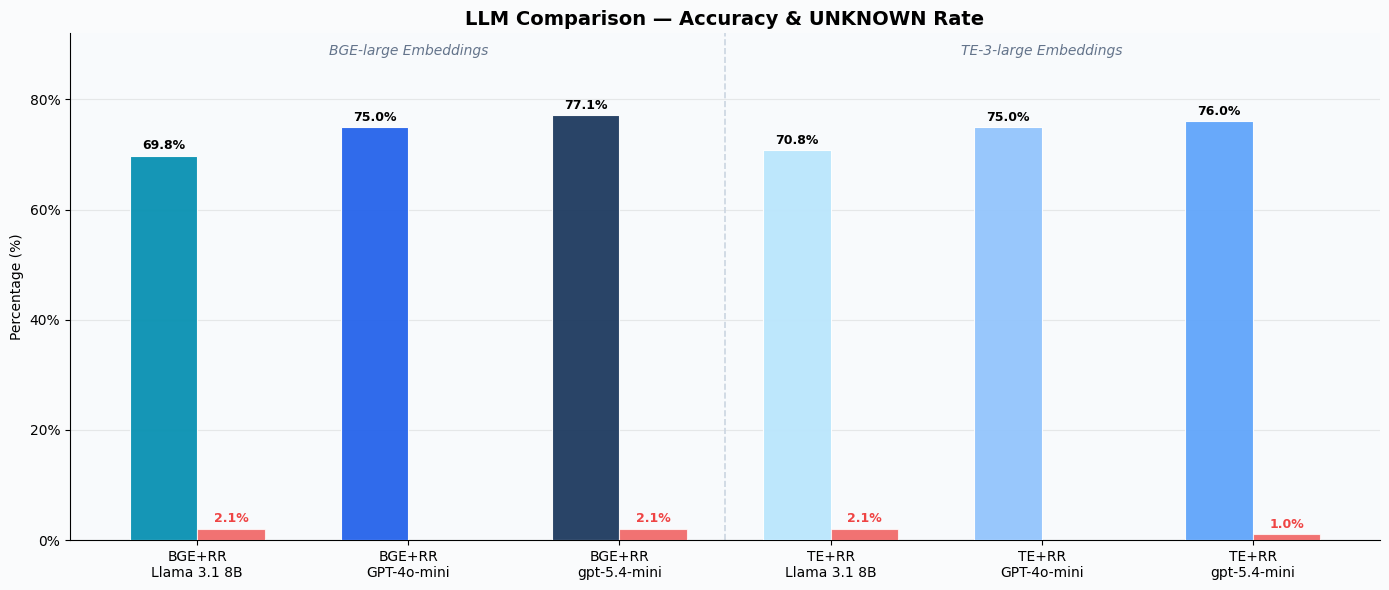

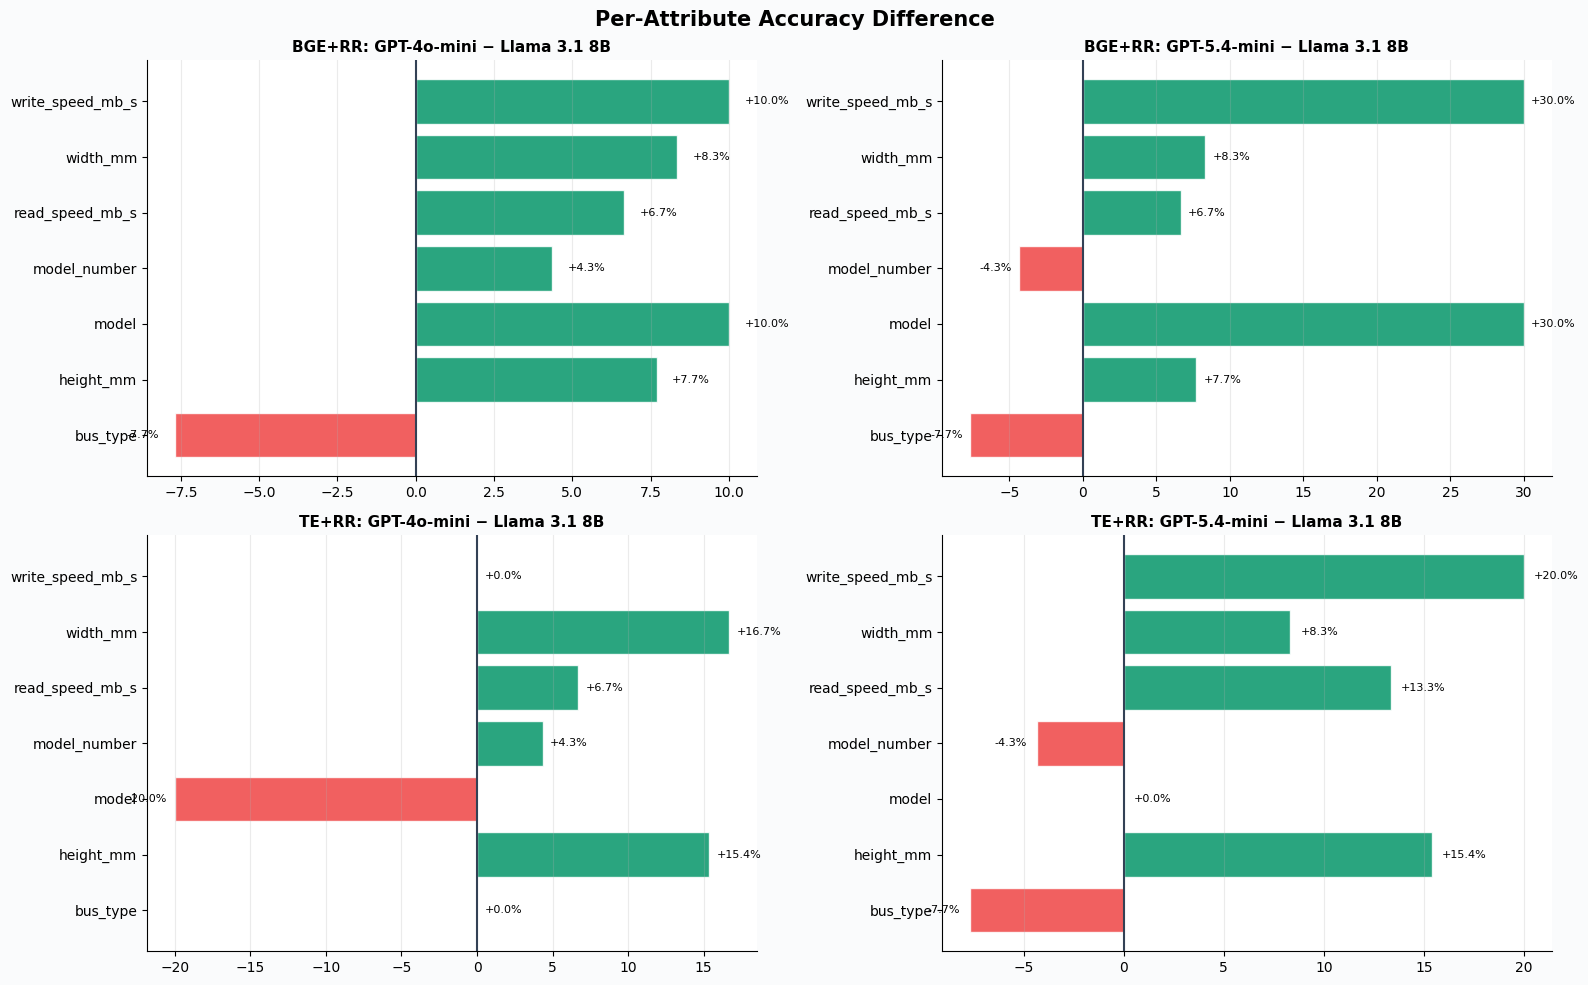


=== Llama correct, GPT-5.4-mini wrong (BGE+RR) ===
Row   Attr                  GT                  Llama                    GPT5                     
4     width_mm              433.0               433 ✓                    70 ✗                     
12    bus_type              PCIe 4.0            PCIe ✓                   PCIe 3.0 x16 ✗           
82    model_number          CT2000P1SSD8        CT2000P1SSD8 ✓           P1 3D NAND NVMe ✗        
21    model_number          PBU240GS25SSDR      PBU240GS25SSDR ✓         PBU120GS25SSDR ✗         

Llama correct, GPT wrong: 4
→ GPT returned UNKNOWN: 0
→ GPT wrong value: 4


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import matplotlib.patches as mp

NUMERIC = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v=p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',',''))==float(str(gt).replace(',',''))
        except: return False
    p,g=str(pred).lower().strip(),str(gt).lower().strip()
    return p==g or p in g or g in p

bge_llama = pd.read_csv('results_ohne_UNKNOWN/exp4_rag_bge_reranker.csv')
bge_gpt4  = pd.read_csv('results_ohne_UNKNOWN/exp6_bge_reranker_gpt4omini.csv')
bge_gpt5   = pd.read_csv('results/exp6_bge_reranker_gpt-5.4-mini.csv')
te_llama  = pd.read_csv('results_ohne_UNKNOWN/exp5_rag_te_reranker.csv')
te_gpt4    = pd.read_csv('results_ohne_UNKNOWN/exp7_te_reranker_gpt4omini.csv')
te_gpt5    = pd.read_csv('results/exp7_te_reranker_gpt-5.4-mini.csv')

# =========================
# PREPROCESSING
# =========================

all_dfs = [
    bge_llama,
    bge_gpt4,
    bge_gpt5,
    te_llama,
    te_gpt4,
    te_gpt5
]

for df in all_dfs:
    df['predicted'] = df['predicted'].apply(fix)
    df['correct'] = df.apply(
        lambda r: correct(
            r['predicted'],
            r['ground_truth'],
            r['attribute']
        ),
        axis=1
    )
    df['unk'] = df['predicted'].apply(is_unk)

# =========================
# OVERALL RESULTS
# =========================

configs = [
    'BGE+RR\nLlama 3.1 8B',
    'BGE+RR\nGPT-4o-mini',
    'BGE+RR\ngpt-5.4-mini',
    'TE+RR\nLlama 3.1 8B',
    'TE+RR\nGPT-4o-mini',
    'TE+RR\ngpt-5.4-mini'
]

dfs = [
    bge_llama,
    bge_gpt4,
    bge_gpt5,
    te_llama,
    te_gpt4,
    te_gpt5
]

acc = [df['correct'].mean()*100 for df in dfs]
unk = [df['unk'].mean()*100 for df in dfs]

print(f'{"Config":<30} {"Accuracy":>10} {"UNKNOWN":>10}')
print('-'*55)

for c,a,u in zip(configs,acc,unk):
    print(f'{c.replace(chr(10)," "):<30} {a:>8.1f}% {u:>8.1f}%')

# =========================
# COLORS
# =========================

C_UNK = '#EF4444'

ACC_COLORS = [
    '#0891B2',  # BGE Llama
    '#2563EB',  # BGE GPT4o
    '#1E3A5F',  # BGE GPT5
    '#BAE6FD',  # TE Llama
    '#93C5FD',  # TE GPT4o
    '#60A5FA'   # TE GPT5
]

# =========================
# FIGURE 1
# =========================

fig, ax = plt.subplots(figsize=(14,6))

fig.patch.set_facecolor('#FAFBFC')
ax.set_facecolor('#F8FAFC')

x = np.arange(len(configs))
w = 0.32

for i in range(len(configs)):

    ax.bar(
        i-w/2,
        acc[i],
        w,
        color=ACC_COLORS[i],
        alpha=0.95,
        edgecolor='white',
        linewidth=0.8,
        zorder=3
    )

    ax.bar(
        i+w/2,
        unk[i],
        w,
        color=C_UNK,
        alpha=0.75,
        edgecolor='white',
        linewidth=0.8,
        zorder=3
    )

    ax.text(
        i-w/2,
        acc[i]+0.6,
        f'{acc[i]:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

    if unk[i] > 0:
        ax.text(
            i+w/2,
            unk[i]+0.6,
            f'{unk[i]:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color=C_UNK
        )

ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=10)

ax.set_ylim(0,92)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_ylabel('Percentage (%)')
ax.set_title(
    'LLM Comparison — Accuracy & UNKNOWN Rate',
    fontsize=14,
    fontweight='bold'
)

ax.grid(axis='y', alpha=0.25)
ax.spines[['top','right']].set_visible(False)

ax.axvline(
    2.5,
    color='#CBD5E1',
    lw=1.2,
    linestyle='--'
)

ax.text(
    1,
    88,
    'BGE-large Embeddings',
    ha='center',
    fontsize=10,
    color='#64748B',
    style='italic'
)

ax.text(
    4,
    88,
    'TE-3-large Embeddings',
    ha='center',
    fontsize=10,
    color='#64748B',
    style='italic'
)

plt.tight_layout()

plt.savefig(
    'figures/llm_comparison_quick_UNKNOWN.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#FAFBFC'
)

plt.show()

# =========================
# FIGURE 2
# GPT4 vs LLAMA
# GPT5 vs LLAMA
# =========================

attrs = sorted(bge_llama['attribute'].unique())

fig, axes = plt.subplots(2, 2, figsize=(16,10))

fig.patch.set_facecolor('#FAFBFC')

comparisons = [

    (
        bge_llama,
        bge_gpt4,
        'BGE+RR: GPT-4o-mini − Llama 3.1 8B'
    ),

    (
        bge_llama,
        bge_gpt5,
        'BGE+RR: GPT-5.4-mini − Llama 3.1 8B'
    ),

    (
        te_llama,
        te_gpt4,
        'TE+RR: GPT-4o-mini − Llama 3.1 8B'
    ),

    (
        te_llama,
        te_gpt5,
        'TE+RR: GPT-5.4-mini − Llama 3.1 8B'
    )
]

for ax, (llama, model, title) in zip(axes.flatten(), comparisons):

    deltas = []

    for attr in attrs:

        d = (
            model[model['attribute']==attr]['correct'].mean()*100
            -
            llama[llama['attribute']==attr]['correct'].mean()*100
        )

        deltas.append(d)

    colors = [
        '#059669' if d >= 0 else '#EF4444'
        for d in deltas
    ]

    y = np.arange(len(attrs))

    ax.barh(
        y,
        deltas,
        color=colors,
        alpha=0.85,
        edgecolor='white'
    )

    for i,v in enumerate(deltas):

        ax.text(
            v + (0.5 if v >= 0 else -0.5),
            i,
            f'{v:+.1f}%',
            va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=8
        )

    ax.set_yticks(y)
    ax.set_yticklabels(attrs)

    ax.axvline(
        0,
        color='#334155',
        lw=1.5
    )

    ax.set_title(
        title,
        fontsize=11,
        fontweight='bold'
    )

    ax.grid(
        axis='x',
        alpha=0.25
    )

    ax.spines[['top','right']].set_visible(False)

plt.suptitle(
    'Per-Attribute Accuracy Difference',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'figures/llm_comparison_delta_quick_UNKNOWN.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#FAFBFC'
)

plt.show()

# =========================
# ROW-BY-ROW ANALYSIS
# BGE GPT5 vs LLAMA
# =========================

print('\n=== Llama correct, GPT-5.4-mini wrong (BGE+RR) ===')

merged = bge_llama[
    ['df1_idx','attribute','ground_truth']
].copy()

merged['llama_pred'] = bge_llama['predicted'].values
merged['gpt_pred'] = bge_gpt5['predicted'].values

merged['llama_correct'] = bge_llama['correct'].values
merged['gpt_correct'] = bge_gpt5['correct'].values

merged['gpt_unk'] = bge_gpt5['unk'].values

interesting = merged[
    merged['llama_correct']
    &
    ~merged['gpt_correct']
]

print(f'{"Row":<6}{"Attr":<22}{"GT":<20}{"Llama":<25}{"GPT5":<25}')
print('='*100)

for _, r in interesting.iterrows():

    gpt_label = (
        'UNKNOWN ✗'
        if r['gpt_unk']
        else str(r['gpt_pred']) + ' ✗'
    )

    print(
        f'{int(r["df1_idx"]):<6}'
        f'{r["attribute"]:<22}'
        f'{str(r["ground_truth"]):<20}'
        f'{str(r["llama_pred"])+" ✓":<25}'
        f'{gpt_label:<25}'
    )

print(f'\nLlama correct, GPT wrong: {len(interesting)}')
print(f'→ GPT returned UNKNOWN: {interesting["gpt_unk"].sum()}')
print(f'→ GPT wrong value: {(~interesting["gpt_correct"] & ~interesting["gpt_unk"]).sum()}')

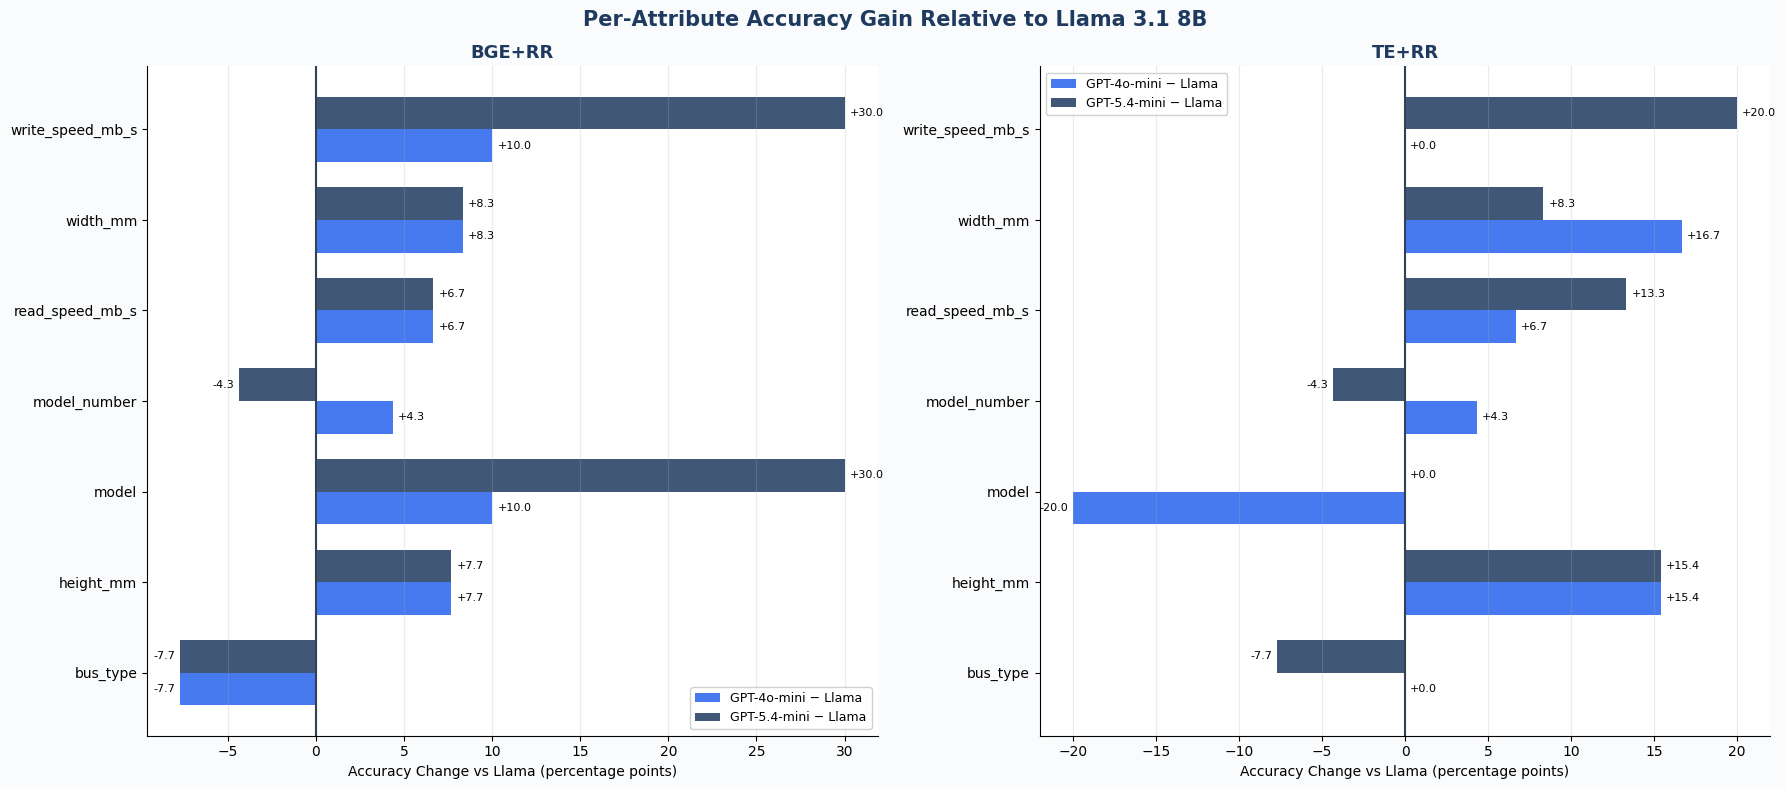

In [4]:
# =========================
# FIGURE 2
# GPT4 vs GPT5 relative to LLAMA
# =========================

attrs = sorted(bge_llama['attribute'].unique())

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#FAFBFC')

comparisons = [

    (
        axes[0],
        bge_llama,
        bge_gpt4,
        bge_gpt5,
        'BGE+RR'
    ),

    (
        axes[1],
        te_llama,
        te_gpt4,
        te_gpt5,
        'TE+RR'
    )
]

for ax, llama, gpt4, gpt5, title in comparisons:

    delta_gpt4 = []
    delta_gpt5 = []

    for attr in attrs:

        llama_acc = (
            llama[llama['attribute'] == attr]['correct']
            .mean() * 100
        )

        gpt4_acc = (
            gpt4[gpt4['attribute'] == attr]['correct']
            .mean() * 100
        )

        gpt5_acc = (
            gpt5[gpt5['attribute'] == attr]['correct']
            .mean() * 100
        )

        delta_gpt4.append(gpt4_acc - llama_acc)
        delta_gpt5.append(gpt5_acc - llama_acc)

    y = np.arange(len(attrs))
    h = 0.36

    bars1 = ax.barh(
        y - h/2,
        delta_gpt4,
        h,
        color='#2563EB',
        alpha=0.85,
        label='GPT-4o-mini − Llama'
    )

    bars2 = ax.barh(
        y + h/2,
        delta_gpt5,
        h,
        color='#1E3A5F',
        alpha=0.85,
        label='GPT-5.4-mini − Llama'
    )

    for i, v in enumerate(delta_gpt4):
        ax.text(
            v + (0.3 if v >= 0 else -0.3),
            i - h/2,
            f'{v:+.1f}',
            va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=8
        )

    for i, v in enumerate(delta_gpt5):
        ax.text(
            v + (0.3 if v >= 0 else -0.3),
            i + h/2,
            f'{v:+.1f}',
            va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=8
        )

    ax.axvline(
        0,
        color='#334155',
        linewidth=1.5
    )

    ax.set_yticks(y)
    ax.set_yticklabels(attrs, fontsize=10)

    ax.set_xlabel(
        'Accuracy Change vs Llama (percentage points)'
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight='bold',
        color='#1E3A5F'
    )

    ax.grid(
        axis='x',
        alpha=0.25
    )

    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        fontsize=9,
        framealpha=0.9
    )

plt.suptitle(
    'Per-Attribute Accuracy Gain Relative to Llama 3.1 8B',
    fontsize=15,
    fontweight='bold',
    color='#1E3A5F'
)

plt.tight_layout()

plt.savefig(
    'figures/llm_comparison_delta_grouped.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#FAFBFC'
)

plt.show()

# Error Analysis (without visualization)

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import CrossEncoder
import glob

NUMERIC = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
HF_CACHE = '/home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub'
CE_SNAP  = glob.glob(f'{HF_CACHE}/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/*/')
CE_PATH  = CE_SNAP[0].rstrip('/') if CE_SNAP else 'cross-encoder/ms-marco-MiniLM-L-6-v2'
cross_encoder = CrossEncoder(CE_PATH)

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v=p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def std_correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',',''))==float(str(gt).replace(',',''))
        except: return False
    p,g=str(pred).lower().strip(),str(gt).lower().strip()
    return p==g or p in g or g in p

def ce_correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try:
            p=float(str(pred).replace(',','').strip())
            g=float(str(gt).replace(',','').strip())
            if g==0: return p==0
            r=abs(p-g)/abs(g)
            return r<=0.10
        except: return False
    score=cross_encoder.predict([[gt,pred]])[0]
    return score>-1.0  # correct or acceptable

# ── Load all files ─────────────────────────────────────────────────────────────
files = {
    'BGE+RR Llama (mit)':  ('results_mit_UNKNOWN/exp4_rag_bge_reranker.csv',   True),
    'BGE+RR GPT (mit)':    ('results_mit_UNKNOWN/exp6_bge_reranker_gpt4omini.csv',          True),
    'TE+RR Llama (mit)':   ('results_mit_UNKNOWN/exp5_rag_te_reranker.csv',     True),
    'TE+RR GPT (mit)':     ('results_mit_UNKNOWN/exp7_te_reranker_gpt4omini.csv',           True),
    'BGE+RR Llama (ohne)': ('results_ohne_UNKNOWN/exp4_rag_bge_reranker.csv',   False),
    'BGE+RR GPT (ohne)':    ('results/exp6_bge_reranker_gpt4omini.csv',          True),
    'TE+RR Llama (ohne)':  ('results_ohne_UNKNOWN/exp5_rag_te_reranker.csv',    False),
    'TE+RR GPT (ohne)':     ('results/exp7_te_reranker_gpt4omini.csv',           True),
}

ATTRS = ['bus_type','model','model_number',
         'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm']
CONFIGS_MIT  = ['BGE+RR Llama (mit)','BGE+RR GPT (mit)','TE+RR Llama (mit)','TE+RR GPT (mit)']
CONFIGS_OHNE = ['BGE+RR Llama (ohne)','BGE+RR GPT (ohne)','TE+RR Llama (ohne)','TE+RR GPT (ohne)']

dfs = {}
for label,(path,_) in files.items():
    try:
        df = pd.read_csv(path)
        df['predicted'] = df['predicted'].apply(fix)
        df['std'] = df.apply(lambda r: std_correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
        df['ce']  = df.apply(lambda r: ce_correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
        df['unk'] = df['predicted'].apply(is_unk)
        dfs[label] = df
        print(f'✓ {label}')
    except FileNotFoundError:
        print(f'✗ NOT FOUND: {path}')

def build_table(config_list, metric):
    """Build attr x config table for a given metric (std or ce)."""
    rows = []
    for attr in ATTRS:
        atype = 'Numeric' if attr in NUMERIC else 'Text'
        row = {'Attribute': attr, 'Type': atype}
        for cfg in config_list:
            if cfg not in dfs: row[cfg] = 'N/A'; continue
            sub = dfs[cfg][dfs[cfg]['attribute']==attr]
            row[cfg] = round(sub[metric].mean()*100, 1)
        rows.append(row)
    # Overall row
    overall = {'Attribute': 'OVERALL', 'Type': ''}
    for cfg in config_list:
        if cfg not in dfs: overall[cfg]='N/A'; continue
        overall[cfg] = round(dfs[cfg][metric].mean()*100, 1)
    rows.append(overall)

    # UNKNOWN rate row
    unk_row = {'Attribute': 'UNKNOWN rate', 'Type': ''}
    for cfg in config_list:
        if cfg not in dfs: unk_row[cfg]='N/A'; continue
        unk_row[cfg] = round(dfs[cfg]['unk'].mean()*100, 1)
    rows.append(unk_row)

    return pd.DataFrame(rows)

# ── Build all 4 tables ────────────────────────────────────────────────────────
std_mit  = build_table(CONFIGS_MIT,  'std')
ce_mit   = build_table(CONFIGS_MIT,  'ce')
std_ohne = build_table(CONFIGS_OHNE, 'std')
ce_ohne  = build_table(CONFIGS_OHNE, 'ce')

# ── Write to Excel ────────────────────────────────────────────────────────────
try:
    import openpyxl
    from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    NAVY  = '1E3A5F'; TEAL  = '0891B2'; GREEN = '059669'
    RED   = 'DC2626'; GOLD  = 'D97706'; WHITE = 'FFFFFF'
    GREY  = 'F1F5F9'; DKGRY = 'CBD5E1'

    def style_sheet(ws, df, title):
        ws.title = title[:31]

        # Title row
        ws.merge_cells(f'A1:{get_column_letter(len(df.columns))}1')
        ws['A1'] = title
        ws['A1'].font      = Font(bold=True, size=13, color=WHITE)
        ws['A1'].fill      = PatternFill('solid', fgColor=NAVY)
        ws['A1'].alignment = Alignment(horizontal='center', vertical='center')
        ws.row_dimensions[1].height = 24

        thin = Side(style='thin', color=DKGRY)
        border = Border(left=thin, right=thin, top=thin, bottom=thin)

        # Header row
        for col_i, col in enumerate(df.columns, 1):
            cell = ws.cell(row=2, column=col_i, value=col)
            cell.font      = Font(bold=True, size=11, color=WHITE)
            cell.fill      = PatternFill('solid', fgColor=TEAL)
            cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
            cell.border    = border
        ws.row_dimensions[2].height = 36

        # Data rows
        for row_i, (_, row) in enumerate(df.iterrows(), 3):
            is_overall = str(row['Attribute']) in {'OVERALL','UNKNOWN rate'}
            is_numeric = row.get('Type','') == 'Numeric'

            for col_i, val in enumerate(row, 1):
                cell = ws.cell(row=row_i, column=col_i, value=val)
                cell.border    = border
                cell.alignment = Alignment(horizontal='center' if col_i>1 else 'left',
                                           vertical='center')

                # Row background
                if is_overall:
                    cell.fill = PatternFill('solid', fgColor='E2E8F0')
                    cell.font = Font(bold=True, size=11)
                elif is_numeric:
                    cell.fill = PatternFill('solid', fgColor='EFF6FF')
                    cell.font = Font(size=11)
                elif row_i % 2 == 0:
                    cell.fill = PatternFill('solid', fgColor=GREY)
                    cell.font = Font(size=11)
                else:
                    cell.font = Font(size=11)

                # Color-code accuracy values
                if col_i > 2 and isinstance(val, (int, float)):
                    if str(row['Attribute']) == 'UNKNOWN rate':
                        # Low UNKNOWN = green, high = red
                        if val <= 5:   cell.font = Font(bold=True, size=11, color=GREEN)
                        elif val >= 20: cell.font = Font(bold=True, size=11, color=RED)
                        else:           cell.font = Font(bold=True, size=11, color=GOLD)
                    else:
                        # High accuracy = green, low = red
                        if val >= 80:   cell.font = Font(bold=True, size=11, color=GREEN)
                        elif val >= 60: cell.font = Font(bold=True, size=11, color='0E7490')
                        elif val < 30:  cell.font = Font(bold=True, size=11, color=RED)
                        else:           cell.font = Font(size=11)

            ws.row_dimensions[row_i].height = 20

        # Column widths
        ws.column_dimensions['A'].width = 22
        ws.column_dimensions['B'].width = 10
        for col_i in range(3, len(df.columns)+1):
            ws.column_dimensions[get_column_letter(col_i)].width = 22

    # ── Sheet 1: MIT UNKNOWN ──────────────────────────────────────────────────
    wb_mit = openpyxl.Workbook()
    ws1 = wb_mit.active
    style_sheet(ws1, std_mit,  'Standard Accuracy — With UNKNOWN')
    ws2 = wb_mit.create_sheet()
    style_sheet(ws2, ce_mit,   'CE Eval Accuracy — With UNKNOWN')

    # ── Sheet 2: OHNE UNKNOWN ─────────────────────────────────────────────────
    wb_ohne = openpyxl.Workbook()
    ws3 = wb_ohne.active
    style_sheet(ws3, std_ohne, 'Standard Accuracy — Forced Prediction')
    ws4 = wb_ohne.create_sheet()
    style_sheet(ws4, ce_ohne,  'CE Eval — Forced Prediction')

    path_mit  = 'results/llm_comparison_mit_unknown.xlsx'
    path_ohne = 'results/llm_comparison_ohne_unknown.xlsx'
    wb_mit.save(path_mit)
    wb_ohne.save(path_ohne)
    print(f'\n✓ {path_mit}')
    print(f'✓ {path_ohne}')

except ImportError:
    print('openpyxl not found — pip install openpyxl --break-system-packages')
    print('\nFallback: saving as CSV')
    std_mit.to_csv('results/std_mit_unknown.csv',   index=False)
    ce_mit.to_csv('results/ce_mit_unknown.csv',    index=False)
    std_ohne.to_csv('results/std_ohne_unknown.csv', index=False)
    ce_ohne.to_csv('results/ce_ohne_unknown.csv',  index=False)
    print('✓ Saved 4 CSV files to results/')